# Assignment 05: Raster Data and Environmental Covariates

## BIO597 Spatial Analysis of Biodiversity

This assignment asks you to repeat and extend the raster workflow from Lab 05. You will clip WorldClim rasters to Maine, extract environmental values for selected amphibian occurrences, compare species, and document your predictor choices.

## Deliverable

Submit a completed notebook containing code, raster maps, an occurrence-environment table, and species summaries.

## Learning goals

By the end of this assignment, you should be able to:

* inspect raster metadata and identify alignment problems
* clip global rasters to a study-area polygon
* extract raster values at point locations
* recognize and retain NoData values
* select predictors based on ecological meaning rather than availability alone
* document a reproducible environmental-data workflow

## Data

Use:

* `Amphibians_ME/Amphibians_ME.csv` for occurrence records
* `/home/jovyan/shared-readwrite/bioclim` for WorldClim 2.1 bioclimatic rasters
* `../labs/ME_ShapeFiles/Maine_State_Boundary.shp` for the clipping boundary

The WorldClim files represent 1970–2000 climate normals at 2.5 arc-minute resolution. Variable definitions are available from the [WorldClim bioclimatic variable page](https://www.worldclim.org/data/bioclim.html).

## 1. Import packages

Import `pandas`, `geopandas`, `rioxarray`, and `xarray` using the same abbreviations as Lab 05.
Also import `Path` from the `pathlib` module as we did previously

In [2]:
# Import the four packages here.
import pandas as pd 
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
from pathlib import Path

## 2. Load and combine the Maine boundary

Read `Maine_State_Boundary.shp`. Inspect its CRS and shape, then use `dissolve()` to combine the polygons.

In [3]:
boundary_path = "../labs/ME_ShapeFiles/"

# Read the boundary.
maine_boundary = gpd.read_file(boundary_path + "Maine_State_Boundary.shp")


# Print its CRS and shape.
print("maine_boundary crs:", maine_boundary.crs)

print("maine_boundary shape:", maine_boundary.shape)

# Dissolve it to one row.
maine_boundary = maine_boundary.dissolve()


maine_boundary crs: EPSG:4326
maine_boundary shape: (6204, 10)


## 3. Open annual mean temperature

Open `wc2.1_2.5m_bio_1.tif` with `masked=True`. Store the result as `bio1`.

In [4]:
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio1_path = bioclim_path / "wc2.1_2.5m_bio_1.tif"

bio1 = rxr.open_rasterio(
    bio1_path,
    masked = True,
)

bio1

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 4. Inspect annual mean temperature metadata

Report:

* dimensions and shape
* data type
* CRS
* resolution
* bounds
* NoData value

Add a brief comment beside each output explaining what it describes.

In [5]:
# Print the requested raster metadata here.
print("Dimensions:", bio1.dims) # Labels of data axes
print("Shape:", bio1.shape) # Number of bands, pixel rows, and pixel columns
print("Data type:", bio1.dtype) # Data type
print("CRS:", bio1.rio.crs) # Coordinate reference system
print("Resolution:", bio1.rio.resolution()) # Pixel size in decimal degrees (arcminutes)
print("Bounds:", bio1.rio.bounds()) # Global extent of dataset
print("NoData:", bio1.rio.nodata) # Representation of missing data

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


## 5. Clip BIO1 to Maine

Use `rio.clip()` with the dissolved boundary. Set `drop=True` and `from_disk=True`, then remove the one-band dimension with `squeeze()`.

In [6]:
bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio1_maine = bio1_maine.squeeze()

## 6. Compare the global and clipped rasters

Display the shape, bounds, CRS, and resolution of both. State which properties changed and which remained the same.

In [7]:
# Compare global and clipped metadata here.
print("Global metadata")
print("Dimensions:", bio1.dims)
print("Shape:", bio1.shape)
print("Data type:", bio1.dtype)
print("CRS:", bio1.rio.crs)
print("Resolution:", bio1.rio.resolution()) 
print("Bounds:", bio1.rio.bounds())
print("No Data:", bio1.rio.nodata)
print()
print("Clipped metadata")
print("Dimensions:", bio1_maine.dims)
print("Shape:", bio1_maine.shape)
print("Data type:", bio1_maine.dtype)
print("CRS:", bio1_maine.rio.crs)
print("Resolution:", bio1_maine.rio.resolution()) 
print("Bounds:", bio1_maine.rio.bounds())
print("No Data:", bio1_maine.rio.nodata)


Global metadata
Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
No Data: nan

Clipped metadata
Dimensions: ('y', 'x')
Shape: (109, 101)
Data type: float64
CRS: EPSG:4326
Resolution: (0.04166666666666671, -0.041666666666666664)
Bounds: (-71.125, 42.95833333333333, -66.91666666666667, 47.5)
No Data: nan


**Your comparison:**

Changed: band dimension, shape (reduced pixels), data type, bounds

Unchanged: CRS, resolution, representation of missing data

## 7. Plot annual mean temperature for Maine

Use the DataArray's `.plot()` method and choose an appropriate colormap.

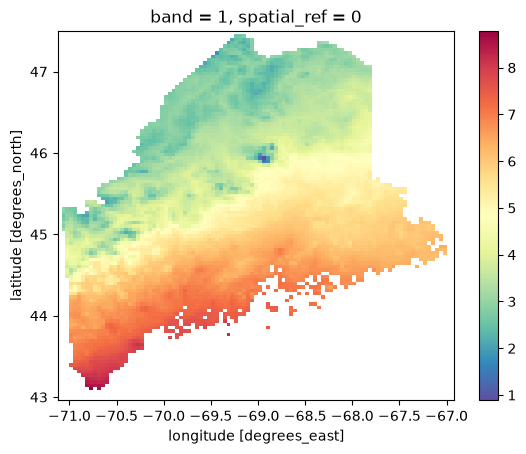

In [8]:
# Plot bio1_maine here.
bio1_maine.plot(cmap="Spectral_r")

## 8. Choose three additional bioclimatic variables

Choose three variables from BIO2 through BIO19. Include at least one temperature variable and at least one precipitation variable.

Do not choose variables only because they are available. Give a short biological reason for each choice.

**Variable 1 and justification:** BIO16, precipitation of the driest quarter. I am unable to provide robust biological reasoning because I know almost nothing about amphibians but am speculating that temporality of moisture patterns might affect some amphibians. Don't some amphibians breathe through their skin and thus have specific moisture requirements?

**Variable 2 and justification:** BIO17, precipitation of the wettest quarter. As with BIO16, I am speculating that temporality of moisture patterns might affect some amphibians. 

**Variable 3 and justification:** BIO7, temperature annual range. I am interested in this variable as a proxy for topography and landscape position, as I would expect higher elevation sites to have a greater temperature range than lower elevation sites. 

## 9. Open the first additional raster

Build its filename, open it with `masked=True`, and inspect its CRS, shape, resolution, and bounds.

In [9]:
# Open your first additional raster, BIO17 (precipitation of the driest quarter)
bio17_path = bioclim_path / "wc2.1_2.5m_bio_17.tif"

bio17 = rxr.open_rasterio(
    bio17_path,
    masked = True,
)

# Inspect its metadata.
print("CRS:", bio17.rio.crs)
print("Shape:", bio17.shape)
print("Resolution:", bio17.rio.resolution()) 
print("Bounds:", bio17.rio.bounds())

CRS: EPSG:4326
Shape: (1, 4320, 8640)
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)


## 10. Check alignment with BIO1

Compare CRS, shape, resolution, and bounds. Each comparison should return `True` before you treat the rasters as an aligned stack.

In [10]:
# Compare the first additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio17.rio.crs)
print("Same shape:", bio1.rio.shape == bio17.rio.shape)
print("Same resolution:", bio1.rio.resolution == bio17.rio.resolution) # Reading as False but they appear the be the same?
print("BIO1 resolution:", bio1.rio.resolution(), "BIO17 resolution:", bio17.rio.resolution())
print("Same bounds:", bio1.rio.bounds == bio17.rio.bounds) # Reading as False but they appear to be the same?
print("BIO1 bounds:", bio1.rio.bounds(), "BIO17 bounds:", bio17.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: False
BIO1 resolution: (0.041666666666666664, -0.041666666666666664) BIO17 resolution: (0.041666666666666664, -0.041666666666666664)
Same bounds: False
BIO1 bounds: (-180.0, -89.99999999999997, 180.0, 90.0) BIO17 bounds: (-180.0, -89.99999999999997, 180.0, 90.0)


## 11. Clip and map the first additional raster

Use the same clipping settings as BIO1. Plot the Maine result with an appropriate colormap.

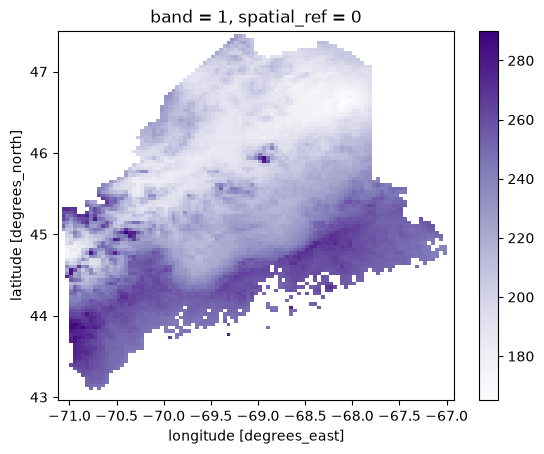

In [11]:
# Clip, squeeze, and plot the first additional raster.
bio17_maine = bio17.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio17_maine = bio17_maine.squeeze()

bio17_maine.plot(cmap="Purples")

## 12. Repeat for the second additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it. Keep each part of the workflow visible in your code.

Same CRS: True
Same shape: True
Same resolution: False
BIO17 resolution: (0.041666666666666664, -0.041666666666666664) BIO16 resolution: (0.041666666666666664, -0.041666666666666664)
Same bounds: True


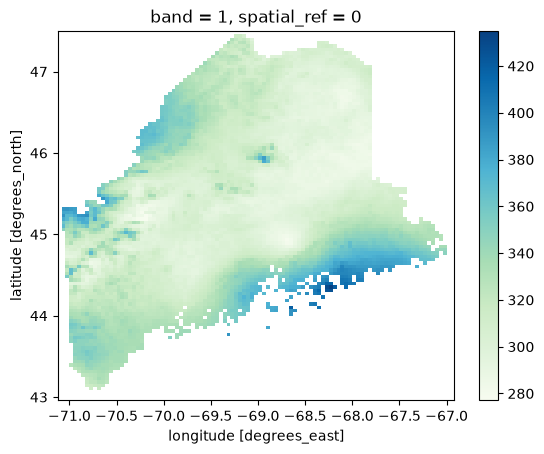

In [16]:
# Complete the workflow for the second additional raster.
# Open your first additional raster, BIO16 (precipitation of the wettest quarter)
bio16_path = bioclim_path / "wc2.1_2.5m_bio_16.tif"

bio16 = rxr.open_rasterio(
    bio16_path,
    masked = True,
)

# Compare BIO16 metadata with BIO1 and BIO17
print("Same CRS:", bio17.rio.crs == bio16.rio.crs)
print("Same shape:", bio17.rio.shape == bio16.rio.shape)
print("Same resolution:", bio17.rio.resolution == bio16.rio.resolution) # Reading as False but they appear the be the same?
print("BIO17 resolution:", bio17.rio.resolution(), "BIO16 resolution:", bio16.rio.resolution())
print("Same bounds:", bio17.rio.bounds == bio17.rio.bounds) # Bounds equal BIO17 bounds but not BIO1

# Clip, squeeze, and plot the second additional raster.
bio16_maine = bio16.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio16_maine = bio16_maine.squeeze()

bio16_maine.plot(cmap="GnBu")

## 13. Repeat for the third additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it.

Same CRS: True
Same shape: True
Same resolution: False
BIO1 resolution: (0.041666666666666664, -0.041666666666666664) BIO7 resolution: (0.041666666666666664, -0.041666666666666664)
Same bounds: False
BIO1 bounds: (-180.0, -89.99999999999997, 180.0, 90.0) BIO7 resolution: (-180.0, -89.99999999999997, 180.0, 90.0)


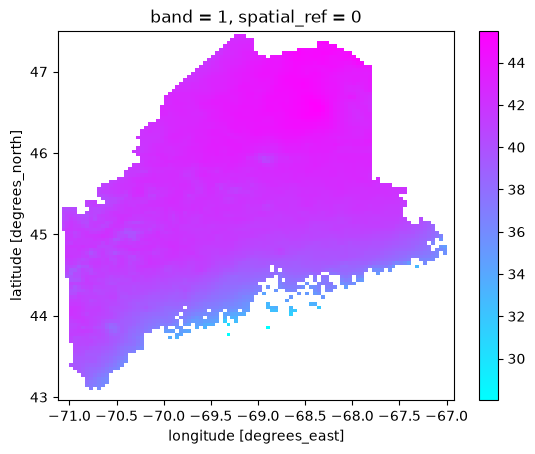

In [19]:
# Complete the workflow for the third additional raster (BIO7, temperature annual range)

bio7_path = bioclim_path / "wc2.1_2.5m_bio_7.tif"

bio7 = rxr.open_rasterio(
    bio7_path,
    masked = True,
)

# Compare BIO7 metadata with BIO1
print("Same CRS:", bio1.rio.crs == bio7.rio.crs)
print("Same shape:", bio1.rio.shape == bio7.rio.shape)
print("Same resolution:", bio1.rio.resolution == bio7.rio.resolution) # Reading as False but they appear the be the same?
print("BIO1 resolution:", bio1.rio.resolution(), "BIO7 resolution:", bio16.rio.resolution())
print("Same bounds:", bio1.rio.bounds == bio7.rio.bounds) # Reading as False but appear to be the same?
print("BIO1 bounds:", bio1.rio.bounds(), "BIO7 resolution:", bio7.rio.bounds())

bio7_maine = bio7.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio7_maine = bio7_maine.squeeze()

bio7_maine.plot(cmap="cool")

## 14. Load the amphibian records

Read the tab-delimited occurrence file. Keep `gbifID`, `species`, longitude, latitude, and year.

In [21]:
amphibians = pd.read_csv(
    "Amphibians_ME/Amphibians_ME.csv",
    sep="\t",
    low_memory=False,
)

# Keep the five requested columns.
columns_to_keep = [
    "gbifID",
    "species",
    "decimalLongitude",
    "decimalLatitude",
    "year",
]

amphibians = amphibians[columns_to_keep]

amphibians

,gbifID,species,decimalLongitude,decimalLatitude,year
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,2026.0
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026.0
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,2026.0
3,6520721493,Lithobates palustris,-68.636788,44.860466,2022.0
4,6520718655,Lithobates pipiens,-68.788851,44.990948,2026.0
...,...,...,...,...,...
25967,476470982,Ambystoma laterale,-68.001670,47.045000,1987.0
25968,476470981,Ambystoma jeffersonianum,-68.215830,46.578060,1987.0
25969,476470394,Ambystoma laterale,-68.913900,44.810000,1987.0
25970,476469978,Desmognathus fuscus,-70.643300,44.966400,1926.0


## 15. Prepare the occurrence coordinates

Convert longitude and latitude to numeric columns. Remove records missing species or coordinates.

In [22]:
# Convert both coordinate columns with pd.to_numeric().
amphibians["decimalLongitude"] = pd.to_numeric(
    amphibians["decimalLongitude"], errors= "coerce"
)
amphibians["decimalLatitude"] = pd.to_numeric(
    amphibians["decimalLatitude"], errors = "coerce"
)
# Drop rows missing species, longitude, or latitude.
amphibians = amphibians.dropna(
    subset=["species", "decimalLongitude", "decimalLatitude"]
).copy()

amphibians.shape
# Dropped 400ish records

(25586, 5)

## 16. Choose three amphibian species

Inspect the species counts, then choose three species with enough records for comparison.

In [23]:
amphibians["species"].value_counts().head(20)

species
Aquarana clamitans            2966
Plethodon cinereus            2864
Pseudacris crucifer           2801
Anaxyrus americanus           2800
Boreorana sylvatica           2794
Ambystoma maculatum           2511
Lithobates catesbeianus       2302
Lithobates palustris          1626
Dryophytes versicolor         1411
Notophthalmus viridescens     1029
Lithobates pipiens             561
Eurycea bislineata             516
Hemidactylium scutatum         334
Ambystoma laterale             322
Desmognathus fuscus            215
Aquarana septentrionalis       198
Gyrinophilus porphyriticus     134
Aquarana catesbeiana            81
Rana arvalis                    54
Ambystoma jeffersonianum        37
Name: count, dtype: int64

**Species 1:** Plethodon cinereus

**Species 2:** Ambystoma maculatum 

**Species 3:** Notophthalmus viridescens

In [24]:
selected_species = [
    "Plethodon cinereus",
    "Ambystoma maculatum",
    "Notophthalmus viridescens",
]

# Filter the occurrence table with .isin(selected_species).
amphibians_selected = amphibians[amphibians["species"].isin(selected_species)]


## 17. Create an occurrence GeoDataFrame

Use longitude and latitude to create point geometry. Assign `EPSG:4326`.

In [25]:
# Create selected_amphibians_gdf here.

selected_amphibians_gdf = gpd.GeoDataFrame(
    amphibians_selected,
    geometry=gpd.points_from_xy(
        amphibians_selected["decimalLongitude"],
        amphibians_selected["decimalLatitude"],
    ),
    crs= "EPSG:4326",
)

selected_amphibians_gdf

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431)
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,POINT (-70.06047 43.8358)
41,6520435603,Notophthalmus viridescens,-67.975203,44.401369,2026.0,POINT (-67.9752 44.40137)
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,POINT (-70.92654 44.04253)
50,6520311010,Notophthalmus viridescens,-69.506005,44.532338,2025.0,POINT (-69.506 44.53234)
...,...,...,...,...,...,...
25954,476480693,Ambystoma maculatum,-69.227500,45.183300,1993.0,POINT (-69.2275 45.1833)
25955,476479670,Plethodon cinereus,-66.990260,44.879800,1862.0,POINT (-66.99026 44.8798)
25956,476477805,Notophthalmus viridescens,-69.415620,44.280520,1993.0,POINT (-69.41562 44.28052)
25959,476474841,Notophthalmus viridescens,-69.774170,45.086670,1994.0,POINT (-69.77417 45.08667)


## 18. Confirm coordinate systems

Print the occurrence CRS and raster CRS. Explain what must be true before extracting raster values.

In [27]:
# Print both coordinate systems.
print("Occurrence CRS", selected_amphibians_gdf.crs)
print("BIO1 CRS", bio1.rio.crs)
print("BIO16 CRS", bio16.rio.crs)
print("BIO17 CRS", bio17.rio.crs)
print("BIO7 CRS", bio7.rio.crs)

Occurrence CRS EPSG:4326
BIO1 CRS EPSG:4326
BIO16 CRS EPSG:4326
BIO17 CRS EPSG:4326
BIO7 CRS EPSG:4326


**Your explanation:** The CRS' of the occurrence records and rasters are the same, which must be true before extracting raster values to occurrence records. If the CRS' don't match, the extraction process will not be able to match the layers in space. 

## 19. Prepare coordinates for extraction

Create `xarray.DataArray` objects called `point_x` and `point_y`. Use one dimension named `record`.

In [28]:
# Create point_x from point longitude.

point_x = xr.DataArray(
    selected_amphibians_gdf.geometry.x.to_numpy(),
    dims="record",
)
# Create point_y from point latitude.
point_y = xr.DataArray(
    selected_amphibians_gdf.geometry.y.to_numpy(),
    dims="record",
)


## 20. Extract annual mean temperature

Use `.sel()` with `x`, `y`, and `method="nearest"`. Add the extracted values to a clearly named column in the occurrence GeoDataFrame.

In [29]:
bio1_values = bio1_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_amphibians_gdf["bio1_mean_temp_c"] = bio1_values
selected_amphibians_gdf.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431),6.875500
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,POINT (-70.06047 43.8358),7.436167
41,6520435603,Notophthalmus viridescens,-67.975203,44.401369,2026.0,POINT (-67.9752 44.40137),6.841288
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,POINT (-70.92654 44.04253),6.673833
50,6520311010,Notophthalmus viridescens,-69.506005,44.532338,2025.0,POINT (-69.506 44.53234),6.708333


## 21. Inspect missing extracted values

Count missing BIO1 values. Explain why coastal occurrences may be assigned NoData even when the coordinates are valid.

In [30]:
# Count missing extracted BIO1 values.
selected_amphibians_gdf["bio1_mean_temp_c"].isna().value_counts()

bio1_mean_temp_c
False    5548
True      856
Name: count, dtype: int64

**Your explanation:** The spatial resolution of the input raster is too coarse to capture the variabiliyt of the coastline in some instances. 

## 22. Extract the three additional variables

Use the same `point_x` and `point_y` arrays. Add one clearly named column for each variable. The column names should include units where practical.

In [31]:
# Extract values from the first additional clipped raster.
bio16_values = bio16_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)
# Add the values to selected_amphibians_gdf.
selected_amphibians_gdf["bio16_wettest_quarter_precip_mm"] = bio16_values

In [32]:
# Extract values from the second additional clipped raster.
bio17_values = bio17_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)
# Add the values to selected_amphibians_gdf.
selected_amphibians_gdf["bio17_driest_quarter_precip_mm"] = bio17_values

In [33]:
# Extract values from the third additional clipped raster.
bio7_values = bio7_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)
# Add the values to selected_amphibians_gdf.
selected_amphibians_gdf["bio7_temp_annual_range_c"] = bio7_values

selected_amphibians_gdf

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c,bio16_wettest_quarter_precip_mm,bio17_driest_quarter_precip_mm,bio7_temp_annual_range_c
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431),6.875500,332.0,258.0,39.531998
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,POINT (-70.06047 43.8358),7.436167,334.0,246.0,36.711998
41,6520435603,Notophthalmus viridescens,-67.975203,44.401369,2026.0,POINT (-67.9752 44.40137),6.841288,406.0,253.0,35.599998
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,POINT (-70.92654 44.04253),6.673833,329.0,258.0,41.944000
50,6520311010,Notophthalmus viridescens,-69.506005,44.532338,2025.0,POINT (-69.506 44.53234),6.708333,308.0,228.0,40.088001
...,...,...,...,...,...,...,...,...,...,...
25954,476480693,Ambystoma maculatum,-69.227500,45.183300,1993.0,POINT (-69.2275 45.1833),5.382167,306.0,226.0,42.007999
25955,476479670,Plethodon cinereus,-66.990260,44.879800,1862.0,POINT (-66.99026 44.8798),NaN,NaN,NaN,NaN
25956,476477805,Notophthalmus viridescens,-69.415620,44.280520,1993.0,POINT (-69.41562 44.28052),6.909667,338.0,260.0,37.860001
25959,476474841,Notophthalmus viridescens,-69.774170,45.086670,1994.0,POINT (-69.77417 45.08667),4.182500,309.0,225.0,41.652000


## 23. Create the occurrence-environment table

Remove the geometry column and display the first five rows. Confirm that the table contains species, coordinates, year, and four environmental variables.

In [34]:
# Create and display occurrence_environment.
occurrence_environment = selected_amphibians_gdf.drop(columns="geometry")

occurrence_environment.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,bio1_mean_temp_c,bio16_wettest_quarter_precip_mm,bio17_driest_quarter_precip_mm,bio7_temp_annual_range_c
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,6.875500,332.0,258.0,39.531998
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,7.436167,334.0,246.0,36.711998
41,6520435603,Notophthalmus viridescens,-67.975203,44.401369,2026.0,6.841288,406.0,253.0,35.599998
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,6.673833,329.0,258.0,41.944000
50,6520311010,Notophthalmus viridescens,-69.506005,44.532338,2025.0,6.708333,308.0,228.0,40.088001


## 24. Summarize environmental values by species

For each selected species, calculate:

* number of records
* mean of each environmental variable
* standard deviation of each environmental variable

In [35]:
# Calculate species-level summaries here.
predictor_columns = [
    "bio1_mean_temp_c",
    "bio16_wettest_quarter_precip_mm",
    "bio17_driest_quarter_precip_mm",
    "bio7_temp_annual_range_c",
]

for species, samples in occurrence_environment.groupby("species"):
    print(species, len(samples), "\n", samples[predictor_columns].mean()) 

Ambystoma maculatum 2511 
 bio1_mean_temp_c                     6.158210
bio16_wettest_quarter_precip_mm    332.126664
bio17_driest_quarter_precip_mm     237.763847
bio7_temp_annual_range_c            39.485545
dtype: float64
Notophthalmus viridescens 1029 
 bio1_mean_temp_c                     6.461556
bio16_wettest_quarter_precip_mm    340.186335
bio17_driest_quarter_precip_mm     244.753623
bio7_temp_annual_range_c            38.740855
dtype: float64
Plethodon cinereus 2864 
 bio1_mean_temp_c                     6.868341
bio16_wettest_quarter_precip_mm    344.158899
bio17_driest_quarter_precip_mm     247.253884
bio7_temp_annual_range_c            37.786927
dtype: float64


## 25. Check relationships among predictors

Create a correlation table for your four environmental variables. Identify any pair with a strong relationship.

In [36]:
# Select the four predictor columns and calculate .corr().
occurrence_environment[predictor_columns].corr().round(2)

,bio1_mean_temp_c,bio16_wettest_quarter_precip_mm,bio17_driest_quarter_precip_mm,bio7_temp_annual_range_c
bio1_mean_temp_c,1.00,0.39,0.76,-0.81
bio16_wettest_quarter_precip_mm,0.39,1.00,0.68,-0.64
bio17_driest_quarter_precip_mm,0.76,0.68,1.00,-0.69
bio7_temp_annual_range_c,-0.81,-0.64,-0.69,1.00


**Interpretation:** Which predictors contain similar information? Would you retain all of them in the same model? Explain your reasoning. All of the selected variables have strong relationships with the exception of BIO1 (mean temp) and BIO16 (precip in the wettest quarter). I would likely not retain both measures of temperature. Shooting in the dark here with my lack of knowledge about amphibians but the strong relationship between precip in the driest and wettest quarters is expected, and I would retain both variables (if they are actually relevant to amphibians to begin with) because there is important temporal information conveyed despite strong relationship. 

In [37]:
# Save your occurrence-environment table
occurrence_environment.to_csv(
    "Assignment05_environmental_values.csv",
    index=False,
)
# Save it as `Assignment05_environmental_values.csv` beside this notebook. Do not include the DataFrame index.

## Final reflection

Answer each question in two or three sentences.

1. How do raster resolution and occurrence-coordinate uncertainty interact? When spatial resolution is low, coordinate uncertainty may have less effect because even with coordinate uncertainty, the records may share extracted raster values if the uncertainty is within the unit size of the raster pixels (or they could not, depending on the placement of the raster pixels and the direction of uncertainty). 
2. What environmental variation is lost when all occurrences in one raster cell receive the same value? Finer scale variation than is able to be observed within a raster cell. This depends on the variable and spatial resolution. 
3. Which predictor has the strongest biological justification for your selected species? Not really sure! I don't know anything about these species except for their names! Hopefully the predictors I chose are relevant. 
4. Which preprocessing choice is most important to document for reproducibility? I would argue that all preprocessing choices are important but the ones that need the most robust documentation would be any preprocessing necessary to make the rasters compatible with one another, especially working across spatial resolutions, because they may be more complex operations. 
5. Name one additional environmental predictor you would seek for an amphibian study and explain why. Eek, these questions about amphibian biology are feeling tricky but my disciplinary background would incline me to include some information about soils (perhaps texture and/or available water holding capacity) because I think amphibians are strongly influenced by moisture and mostly live on the ground (I think? Maybe except for tree frogs?), and the interaction of soils with precipitation variables will have implications for how much moisture is available in their habitat. 

## Submit your work

Run the notebook from top to bottom. Make sure all raster maps, tables, and written answers are complete. Then commit and push the completed notebook to your class GitHub repository.

```bash
git add docs/assignments/Assignment-05-RasterData.ipynb
git commit -m "Complete raster data assignment"
git push
```